<a href="https://colab.research.google.com/github/TramSt/decision-tree-pima-diabetes/blob/main/notebooks/02_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌳 Notebook 02 — Decision Tree Model
**Chủ đề 12:** Cây Quyết Định Phân Loại Bệnh Tiểu Đường (Pima Indians)

| Phần | Thành viên phụ trách |
|------|----------------------|
| Setup & Preprocessing | Nguyễn Thị Trâm |
| Train Decision Tree (Baseline) | Trần Thị Yến Nhi · Nguyễn Thị Trâm |
| Tối ưu với GridSearchCV | Lê Tấn Phú · Nguyễn Thị Trâm |
| Metrics & ROC Curve | Nguyễn Thị Mỹ Quyên · Nguyễn Thị Trâm |
| Trực quan cây & Feature Importance | Trần Thị Yến Nhi · Nguyễn Thị Trâm |
| Kết luận | Nguyễn Thị Trâm |

> ⚠️ **Lưu ý y tế:** Trong bài toán phân loại bệnh, **Recall** quan trọng hơn Accuracy
> vì bỏ sót người bệnh (False Negative) nguy hiểm hơn báo nhầm (False Positive).

## 1. Import Thư Viện
*Nguyễn Thị Trâm*

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay
)

import warnings
warnings.filterwarnings("ignore")
print("✅ Import thành công")

✅ Import thành công


## 2. Load Dữ Liệu & Preprocessing
*Nguyễn Thị Trâm · Kiều Trung Đạt*

> Lặp lại bước làm sạch và split từ `01_eda.ipynb` để notebook này chạy độc lập.

In [7]:
# Nếu chạy độc lập (chưa clone), bỏ comment block bên dưới:
!rm -rf decision-tree-pima-diabetes
!git clone https://github.com/TramSt/decision-tree-pima-diabetes.git
%cd decision-tree-pima-diabetes

df = pd.read_csv("data/diabetes.csv")

# Làm sạch: thay 0 → NaN cho các cột bất hợp lý về y học
invalid_zero_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
df_clean = df.copy()
df_clean[invalid_zero_cols] = df_clean[invalid_zero_cols].replace(0, np.nan)

X = df_clean.drop("Outcome", axis=1)
y = df_clean["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Tỷ lệ dương tính – Train: {y_train.mean():.2%}  |  Test: {y_test.mean():.2%}")

Cloning into 'decision-tree-pima-diabetes'...
remote: Enumerating objects: 117, done.
remote: Counting objects: 100% (117/117), done.
remote: Compressing objects: 100% (106/106), done.
remote: Total 117 (delta 45), reused 3 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (117/117), 1.48 MiB | 5.15 MiB/s, done.
Resolving deltas: 100% (45/45), done.
/content/decision-tree-pima-diabetes/decision-tree-pima-diabetes/decision-tree-pima-diabetes
Train: (614, 8)  |  Test: (154, 8)
Tỷ lệ dương tính – Train: 34.85%  |  Test: 35.06%


In [8]:
# Hàm đánh giá model (tái sử dụng)
def evaluate_model(model, X_test, y_test, title="Model"):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

    metrics = {
        "Accuracy" : accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall"   : recall_score(y_test, y_pred),
        "F1-score" : f1_score(y_test, y_pred),
    }
    if y_prob is not None:
        metrics["ROC-AUC"] = roc_auc_score(y_test, y_prob)

    print(f"{'='*48}")
    print(f"  {title}")
    print(f"{'='*48}")
    for k, v in metrics.items():
        flag = "  ← ưu tiên trong y tế" if k == "Recall" else ""
        print(f"  {k:<12}: {v:.4f}{flag}")
    print()
    print(classification_report(y_test, y_pred,
          target_names=["Không tiểu đường", "Tiểu đường"]))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
                xticklabels=["Pred: 0", "Pred: 1"],
                yticklabels=["Actual: 0", "Actual: 1"])
    axes[0].set_title(f"Confusion Matrix\n{title}", fontweight="bold")

    if y_prob is not None:
        RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1], name=title)
        axes[1].set_title(f"ROC Curve — {title}", fontweight="bold")
        axes[1].plot([0, 1], [0, 1], "k--", alpha=0.4)

    plt.tight_layout()
    plt.show()
    return metrics

## 3. Train Decision Tree — Baseline
*Trần Thị Yến Nhi · Nguyễn Thị Trâm*

> Huấn luyện Decision Tree với tham số mặc định (chưa tối ưu) để làm baseline so sánh.

In [9]:
# Pipeline: Imputer → Scaler → Decision Tree (mặc định)
dt_baseline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
    ("clf",     DecisionTreeClassifier(random_state=42))
])

dt_baseline.fit(X_train, y_train)
print("✅ Decision Tree Baseline đã huấn luyện xong")
print(f"   Số nodes: {dt_baseline.named_steps['clf'].tree_.node_count}")
print(f"   Max depth thực tế: {dt_baseline.named_steps['clf'].get_depth()}")

✅ Decision Tree Baseline đã huấn luyện xong
   Số nodes: 221
   Max depth thực tế: 14


  Decision Tree — Baseline
  Accuracy    : 0.6818
  Precision   : 0.5532
  Recall      : 0.4815  ← ưu tiên trong y tế
  F1-score    : 0.5149
  ROC-AUC     : 0.6357

                  precision    recall  f1-score   support

Không tiểu đường       0.74      0.79      0.76       100
      Tiểu đường       0.55      0.48      0.51        54

        accuracy                           0.68       154
       macro avg       0.65      0.64      0.64       154
    weighted avg       0.67      0.68      0.68       154



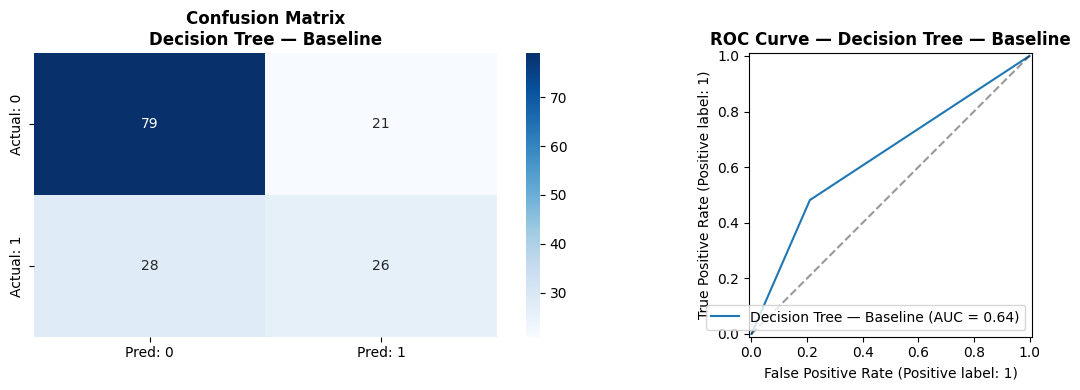

In [10]:
metrics_baseline = evaluate_model(dt_baseline, X_test, y_test,
                                   title="Decision Tree — Baseline")

**Nhận xét:**
Nhìn chung, mô hình cây quyết định ban đầu đạt hiệu suất ở mức trung bình và chưa phù hợp với yêu cầu của bài toán y tế.


Cụ thể, Accuracy đạt 0.6818, Precision đạt 0.5532, trong khi Recall chỉ đạt 0.4815 — đây là một giá trị khá thấp đối với bài toán phát hiện bệnh tiểu đường. Ngoài ra, F1-score đạt 0.5149 và ROC-AUC chỉ ở mức 0.6357.

Phân tích sâu hơn từ confusion matrix cho thấy mô hình dự đoán đúng nhiều trường hợp không mắc bệnh, nhưng lại bỏ sót khá nhiều trường hợp mắc bệnh (false negative).


So với yêu cầu trong lĩnh vực y tế, Recall là chỉ số quan trọng nhất, và mức dưới 0.5 cho thấy mô hình chưa đáp ứng tốt nhiệm vụ.

Điều này cho thấy mô hình baseline có xu hướng thiên về dự đoán lớp “không bệnh”, dẫn đến nguy cơ bỏ sót bệnh nhân — một vấn đề nghiêm trọng trong thực tế.

In [11]:
# Cross-validation 5-fold để đánh giá ổn định
cv_scores = cross_val_score(dt_baseline, X, y, cv=5, scoring="recall")
print(f"Cross-validation Recall (5-fold):")
print(f"  Scores: {cv_scores.round(4)}")
print(f"  Mean  : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

Cross-validation Recall (5-fold):
  Scores: [0.5741 0.6481 0.5    0.6415 0.6415]
  Mean  : 0.6010 ± 0.0573


**Nhận xét:**

Nhìn chung, mô hình có mức độ ổn định tương đối qua các lần chia dữ liệu.

Recall trung bình đạt khoảng 0.6010 với độ lệch chuẩn khoảng ±0.0573, cho thấy sự dao động không quá lớn giữa các fold.

Điều này chứng tỏ mô hình không bị phụ thuộc quá nhiều vào một tập dữ liệu cụ thể, tuy nhiên hiệu suất tổng thể vẫn chưa cao.

## 4. Tối Ưu Siêu Tham Số — GridSearchCV
*Lê Tấn Phú · Nguyễn Thị Trâm*

> GridSearch tìm bộ tham số tối ưu. Scoring = `recall` vì ưu tiên **bắt đúng người bệnh**.

| Tham số | Ý nghĩa |
|---------|---------|
| `max_depth` | Giới hạn độ sâu cây → tránh overfitting |
| `min_samples_split` | Số mẫu tối thiểu để chia node |
| `min_samples_leaf` | Số mẫu tối thiểu ở lá |
| `criterion` | Tiêu chí phân chia (Gini / Entropy) |

In [12]:
# Pipeline để GridSearch
dt_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
    ("clf",     DecisionTreeClassifier(random_state=42))
])

param_grid = {
    "clf__max_depth"        : [3, 4, 5, 7, 10, None],
    "clf__min_samples_split": [2, 5, 10, 20],
    "clf__min_samples_leaf" : [1, 2, 4, 8],
    "clf__criterion"        : ["gini", "entropy"]
}

grid_search = GridSearchCV(
    dt_pipe,
    param_grid,
    cv=5,
    scoring="recall",   # ← ưu tiên Recall (bắt bệnh)
    n_jobs=-1,
    verbose=0,
    return_train_score=True
)

grid_search.fit(X_train, y_train)

print("✅ GridSearch hoàn tất!")
print(f"\nBest params  : {grid_search.best_params_}")
print(f"Best CV Recall: {grid_search.best_score_:.4f}")

✅ GridSearch hoàn tất!

Best params  : {'clf__criterion': 'entropy', 'clf__max_depth': None, 'clf__min_samples_leaf': 8, 'clf__min_samples_split': 20}
Best CV Recall: 0.6355


In [13]:
# Top 10 kết quả GridSearch
results_df = pd.DataFrame(grid_search.cv_results_)
top10 = (results_df[["param_clf__max_depth","param_clf__min_samples_split",
                       "param_clf__min_samples_leaf","param_clf__criterion",
                       "mean_test_score","std_test_score"]]
         .sort_values("mean_test_score", ascending=False)
         .head(10)
         .reset_index(drop=True))
top10.columns = ["max_depth","min_samples_split","min_samples_leaf","criterion","CV_Recall","Std"]
top10.style.background_gradient(subset=["CV_Recall"], cmap="Greens").format({"CV_Recall":"{:.4f}","Std":"{:.4f}"})

,max_depth,min_samples_split,min_samples_leaf,criterion,CV_Recall,Std
0,None,20,8,entropy,0.6355,0.0475
1,10,20,8,entropy,0.6309,0.0420
2,7,20,8,entropy,0.6173,0.0680
3,10,5,8,entropy,0.6120,0.0515
4,None,2,8,entropy,0.6120,0.0515
5,10,10,8,entropy,0.6120,0.0515
6,None,10,8,entropy,0.6120,0.0515
7,None,5,8,entropy,0.6120,0.0515
8,10,2,8,entropy,0.6120,0.0515
9,7,5,8,entropy,0.5984,0.0517


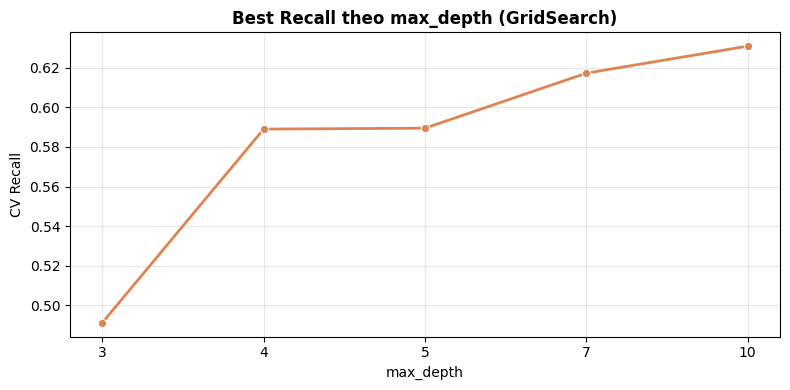

In [14]:
# Ảnh hưởng của max_depth đến Recall
depth_results = results_df.groupby("param_clf__max_depth")["mean_test_score"].max().reset_index()
depth_results.columns = ["max_depth", "best_recall"]
depth_results["max_depth"] = depth_results["max_depth"].astype(str)

plt.figure(figsize=(8, 4))
sns.lineplot(data=depth_results, x="max_depth", y="best_recall",
             marker="o", color="#DD8452", linewidth=2)
plt.title("Best Recall theo max_depth (GridSearch)", fontweight="bold")
plt.xlabel("max_depth"); plt.ylabel("CV Recall")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

In [15]:
# Model tốt nhất
best_model = grid_search.best_estimator_
best_dt = best_model.named_steps["clf"]

print(f"Tham số tốt nhất:")
print(f"  max_depth         : {best_dt.max_depth}")
print(f"  min_samples_split : {best_dt.min_samples_split}")
print(f"  min_samples_leaf  : {best_dt.min_samples_leaf}")
print(f"  criterion         : {best_dt.criterion}")
print(f"  Depth thực tế     : {best_dt.get_depth()}")
print(f"  Số nodes          : {best_dt.tree_.node_count}")

Tham số tốt nhất:
  max_depth         : None
  min_samples_split : 20
  min_samples_leaf  : 8
  criterion         : entropy
  Depth thực tế     : 12
  Số nodes          : 75


**Nhận xét:**
Nhìn chung, việc sử dụng GridSearchCV giúp cải thiện hiệu suất mô hình bằng cách tìm ra bộ tham số phù hợp.

Mô hình tốt nhất sử dụng:

criterion = entropy

min_samples_split = 20

min_samples_leaf = 8

max_depth = None

Recall cross-validation đạt khoảng 0.6355, cao hơn so với baseline.

Analysis sâu

min_samples_leaf = 8 giúp giảm overfitting bằng cách tránh tạo các node quá nhỏ

min_samples_split = 20 làm cho việc chia node “chặt chẽ” hơn
entropy giúp phân tách dữ liệu tốt hơn trong trường hợp dữ liệu phức tạp
Do đó, các tham số như min_samples_leaf và min_samples_split giúp giảm overfitting và tăng khả năng tổng quát hóa của mô hình.
Điều này cho thấy việc kiểm soát độ phức tạp của cây là yếu tố quan trọng để cải thiện khả năng tổng quát hóa.

## 5. Đánh Giá Model Tốt Nhất — Metrics & ROC
*Nguyễn Thị Mỹ Quyên · Nguyễn Thị Trâm*

> So sánh **Baseline** vs **Best (Tuned)** Decision Tree trên tập test.

  Decision Tree — Tuned (GridSearch)
  Accuracy    : 0.7143
  Precision   : 0.6087
  Recall      : 0.5185  ← ưu tiên trong y tế
  F1-score    : 0.5600
  ROC-AUC     : 0.7977

                  precision    recall  f1-score   support

Không tiểu đường       0.76      0.82      0.79       100
      Tiểu đường       0.61      0.52      0.56        54

        accuracy                           0.71       154
       macro avg       0.68      0.67      0.67       154
    weighted avg       0.71      0.71      0.71       154



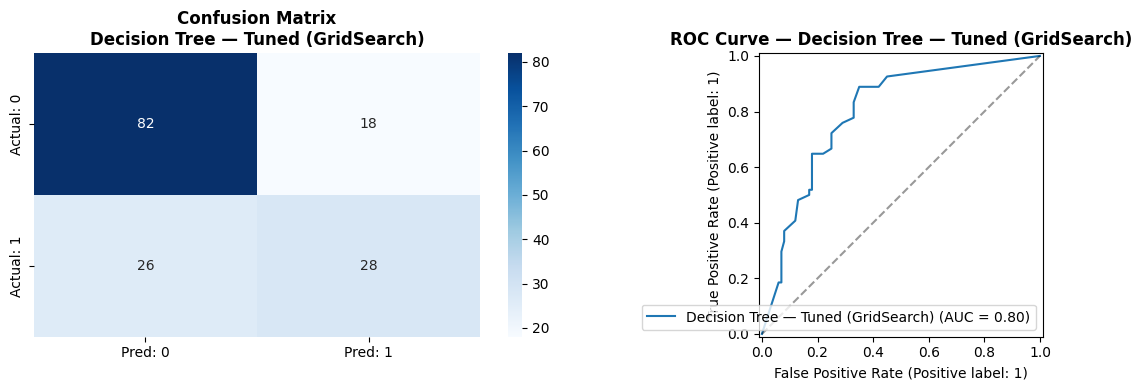

In [16]:
metrics_tuned = evaluate_model(best_model, X_test, y_test,
                               title="Decision Tree — Tuned (GridSearch)")

**Nhận xét:**
Nhìn chung, mô hình sau khi tối ưu có sự cải thiện rõ rệt về hiệu suất.

Accuracy tăng từ 0.6818 → 0.7143

Precision tăng từ 0.5532 → 0.6087

Recall tăng từ 0.4815 → 0.5185

F1-score tăng từ 0.5149 → 0.5600

ROC-AUC tăng mạnh từ 0.6357 → 0.7977

Mặc dù Recall chỉ tăng nhẹ ( ~ 3.7%), nhưng ROC-AUC tăng rất mạnh (~0.16), cho thấy mô hình cải thiện đáng kể khả năng phân biệt hai lớp.

Điều này chứng tỏ mô hình sau tối ưu không chỉ dự đoán tốt hơn mà còn “hiểu” dữ liệu tốt hơn ở mức tổng thể.

Nhìn chung, khi tăng độ sâu của cây, Recall có xu hướng tăng nhưng không ổn định.

Điều này cho thấy nếu cây quá sâu, mô hình có thể bị overfitting.

In [17]:
# Bảng so sánh Baseline vs Tuned
comparison = pd.DataFrame({
    "Metric"  : ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    "Baseline": list(metrics_baseline.values()),
    "Tuned"   : list(metrics_tuned.values()),
})
comparison["Δ (Tuned − Baseline)"] = (comparison["Tuned"] - comparison["Baseline"]).round(4)
comparison = comparison.set_index("Metric")

comparison.style     .format("{:.4f}")     .background_gradient(subset=["Tuned"], cmap="Greens")     .applymap(lambda v: "color: green; font-weight: bold" if v > 0 else "color: red",
              subset=["Δ (Tuned − Baseline)"])

,Baseline,Tuned,Δ (Tuned − Baseline)
Metric,,,
Accuracy,0.6818,0.7143,0.0325
Precision,0.5532,0.6087,0.0555
Recall,0.4815,0.5185,0.0370
F1-score,0.5149,0.5600,0.0451
ROC-AUC,0.6357,0.7977,0.1619


Nhìn chung, mô hình sau khi tối ưu đã cải thiện rõ rệt so với baseline.

Cụ thể, Accuracy, Precision, Recall và đặc biệt là ROC-AUC đều tăng, trong đó ROC-AUC tăng mạnh nhất.

Điều này cho thấy mô hình có khả năng phân biệt giữa hai lớp tốt hơn.

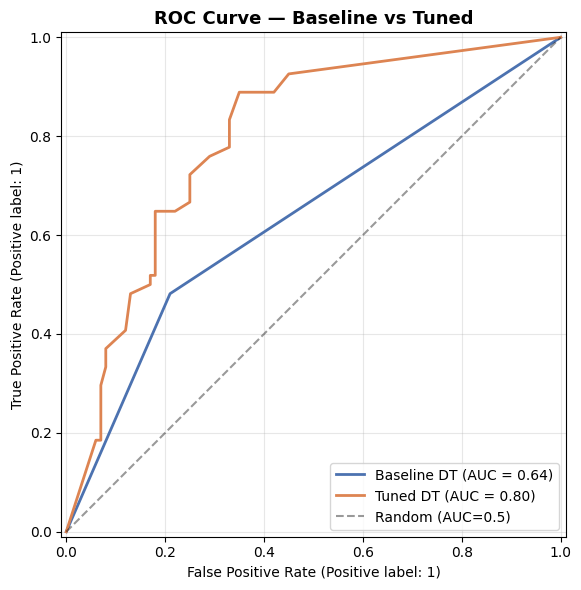

In [18]:
# ROC Curve so sánh cả hai
fig, ax = plt.subplots(figsize=(7, 6))

for model, label, color in [
    (dt_baseline, "Baseline DT", "#4C72B0"),
    (best_model,  "Tuned DT",    "#DD8452"),
]:
    y_prob = model.predict_proba(X_test)[:, 1]
    RocCurveDisplay.from_predictions(y_test, y_prob, ax=ax, name=label,
                                      color=color, linewidth=2)

ax.plot([0,1],[0,1],"k--", alpha=0.4, label="Random (AUC=0.5)")
ax.set_title("ROC Curve — Baseline vs Tuned", fontsize=13, fontweight="bold")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

Nhìn chung, đường ROC của mô hình tuned nằm cao hơn so với baseline.

Điều này cho thấy khả năng phân loại của mô hình sau tối ưu tốt hơn đáng kể.

**Nhận xét:** đường ROC của mô hình tuned nằm cao hơn rõ rệt so với baseline.

Giá trị AUC đạt khoảng 0.80, trong khi baseline chỉ khoảng 0.64.

Phân tích sâu

AUC gần 0.8 cho thấy xác suất mô hình xếp hạng đúng một cặp (bệnh – không bệnh) là khá cao.

Điều này đặc biệt quan trọng trong y tế vì mô hình có thể hỗ trợ sàng lọc bệnh hiệu quả hơn.

## 6. Trực Quan Hoá Cây & Feature Importance
*Trần Thị Yến Nhi · Nguyễn Thị Trâm*

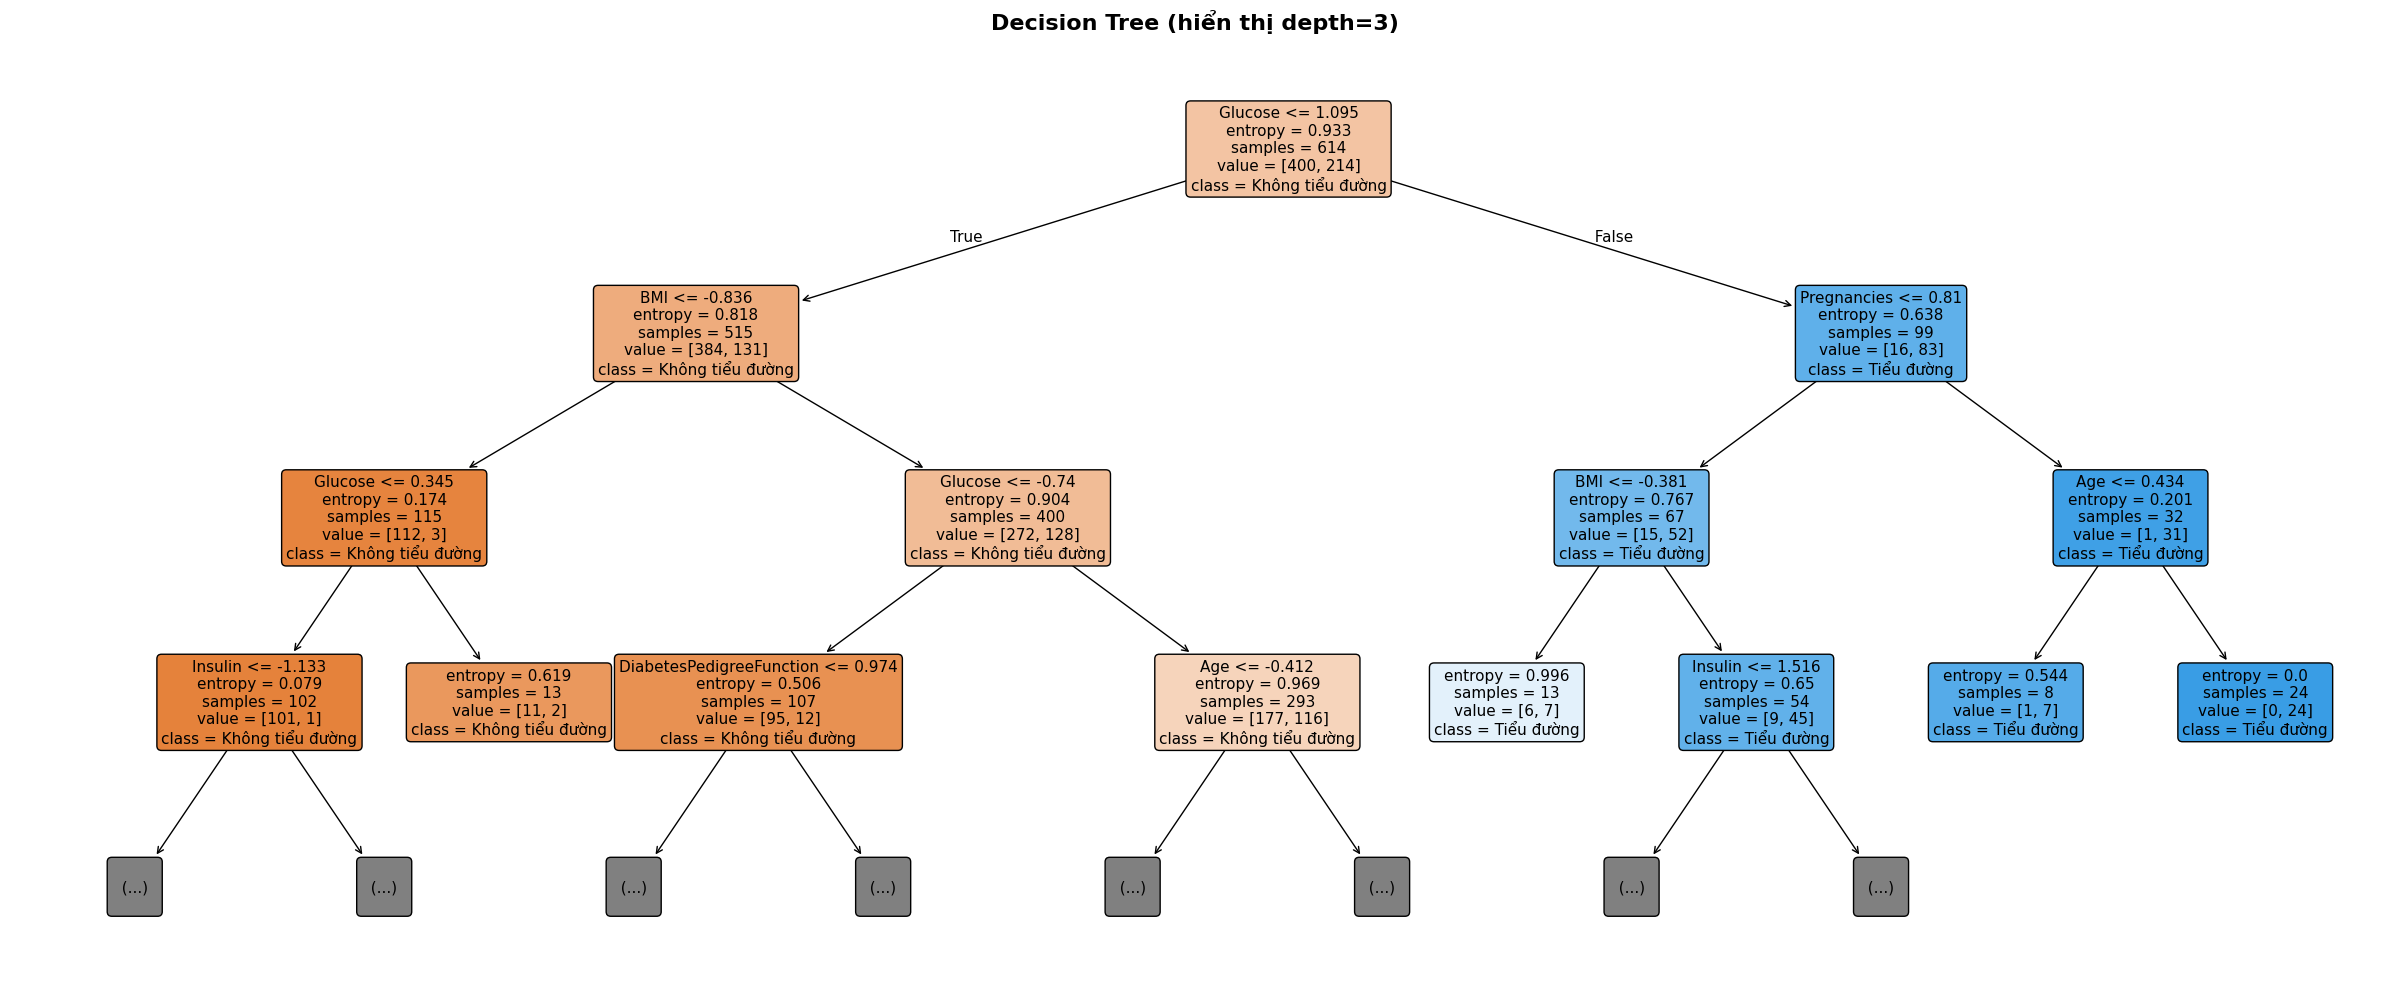

In [19]:
# 6.1 Vẽ cây Decision Tree (giới hạn depth=3 để dễ đọc)
plt.figure(figsize=(24, 10))
plot_tree(
    best_dt,
    max_depth=3,
    feature_names=list(X.columns),
    class_names=["Không tiểu đường", "Tiểu đường"],
    filled=True,
    rounded=True,
    fontsize=11,
    impurity=True,
    precision=3
)
plt.title("Decision Tree (hiển thị depth=3)", fontsize=16, fontweight="bold", pad=20)
plt.tight_layout()
plt.show()

In [20]:
# 6.2 In cấu trúc cây dạng text (depth=3)
tree_text = export_text(best_dt, feature_names=list(X.columns), max_depth=3)
print(tree_text)

|--- Glucose <= 1.10
|   |--- BMI <= -0.84
|   |   |--- Glucose <= 0.34
|   |   |   |--- Insulin <= -1.13
|   |   |   |   |--- class: 0
|   |   |   |--- Insulin >  -1.13
|   |   |   |   |--- class: 0
|   |   |--- Glucose >  0.34
|   |   |   |--- class: 0
|   |--- BMI >  -0.84
|   |   |--- Glucose <= -0.74
|   |   |   |--- DiabetesPedigreeFunction <= 0.97
|   |   |   |   |--- truncated branch of depth 4
|   |   |   |--- DiabetesPedigreeFunction >  0.97
|   |   |   |   |--- class: 0
|   |   |--- Glucose >  -0.74
|   |   |   |--- Age <= -0.41
|   |   |   |   |--- truncated branch of depth 6
|   |   |   |--- Age >  -0.41
|   |   |   |   |--- truncated branch of depth 9
|--- Glucose >  1.10
|   |--- Pregnancies <= 0.81
|   |   |--- BMI <= -0.38
|   |   |   |--- class: 1
|   |   |--- BMI >  -0.38
|   |   |   |--- Insulin <= 1.52
|   |   |   |   |--- truncated branch of depth 3
|   |   |   |--- Insulin >  1.52
|   |   |   |   |--- class: 1
|   |--- Pregnancies >  0.81
|   |   |--- Age <= 0.43

Feature Importance (từ cao đến thấp):
                 Feature  Importance
                 Glucose    0.429706
                     BMI    0.182318
                     Age    0.103965
DiabetesPedigreeFunction    0.099928
                 Insulin    0.060253
           BloodPressure    0.047943
             Pregnancies    0.045509
           SkinThickness    0.030378


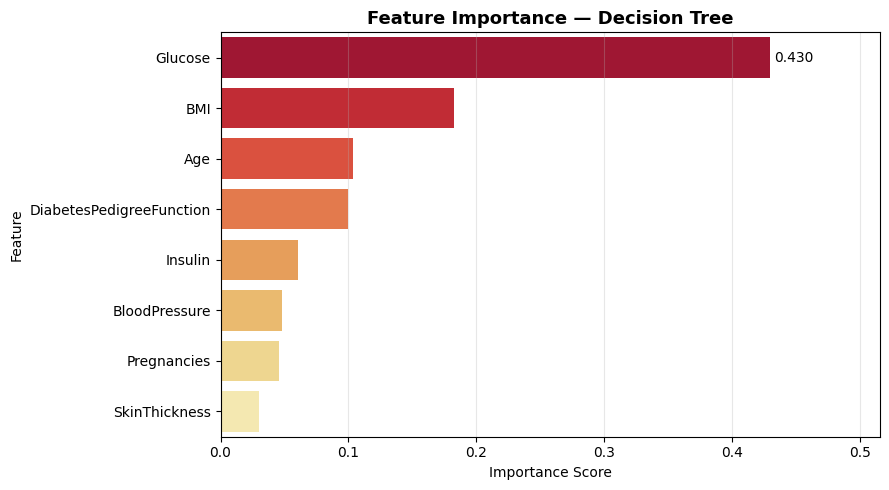

In [21]:
# 6.3 Feature Importance
importances = best_dt.feature_importances_
feat_df = (pd.DataFrame({"Feature": X.columns, "Importance": importances})
           .sort_values("Importance", ascending=False)
           .reset_index(drop=True))

print("Feature Importance (từ cao đến thấp):")
print(feat_df.to_string(index=False))

plt.figure(figsize=(9, 5))
bars = sns.barplot(x="Importance", y="Feature", data=feat_df,
                   palette="YlOrRd_r", orient="h")
plt.bar_label(bars.containers[0], fmt="%.3f", fontsize=10, padding=3)
plt.title("Feature Importance — Decision Tree", fontsize=13, fontweight="bold")
plt.xlabel("Importance Score"); plt.xlim(0, feat_df["Importance"].max() * 1.2)
plt.grid(axis="x", alpha=0.3); plt.tight_layout(); plt.show()

**Nhận xét:** cây quyết định có cấu trúc rõ ràng và dễ diễn giải.

Node gốc sử dụng biến Glucose để phân tách dữ liệu, sau đó các biến như BMI, Age và Insulin tiếp tục được sử dụng ở các node tiếp theo.

Việc Glucose nằm ở node gốc cho thấy đây là feature có khả năng phân tách dữ liệu tốt nhất (information gain cao nhất).

Điều này hoàn toàn phù hợp với thực tế y khoa, vì glucose là chỉ số quan trọng nhất trong chẩn đoán bệnh.

In [22]:
# 6.4 Giải thích y khoa — top 3 features
print("=" * 55)
print("  GIẢI THÍCH Y KHOA — TOP FEATURES")
print("=" * 55)
for i, row in feat_df.head(3).iterrows():
    print(f"\n#{i+1}  {row['Feature']}  (importance = {row['Importance']:.3f})")
    explanations = {
        "Glucose"                 : "Nồng độ glucose huyết tương 2h sau uống đường. Đây là chỉ số trực tiếp nhất để chẩn đoán tiểu đường. Glucose ≥ 140 mg/dL → nguy cơ cao.",
        "BMI"                     : "Chỉ số khối cơ thể. BMI ≥ 30 (béo phì) làm tăng đề kháng insulin → tăng nguy cơ tiểu đường type 2.",
        "Age"                     : "Tuổi càng cao, chức năng tuyến tụy suy giảm, tích tụ mỡ nội tạng → nguy cơ tăng dần.",
        "DiabetesPedigreeFunction": "Hàm phả hệ — phản ánh tiền sử gia đình mắc tiểu đường. Yếu tố di truyền đóng vai trò quan trọng.",
        "Pregnancies"             : "Số lần mang thai liên quan đến tiểu đường thai kỳ — tăng nguy cơ tiểu đường type 2 về sau.",
        "Insulin"                 : "Mức insulin huyết thanh 2h phản ánh khả năng bài tiết và đề kháng insulin.",
        "BloodPressure"           : "Huyết áp tâm trương. Tăng huyết áp thường đi kèm với hội chứng chuyển hóa.",
        "SkinThickness"           : "Độ dày nếp gấp da cơ tam đầu — ước lượng mỡ dưới da, liên quan đến đề kháng insulin.",
    }
    print(f"  → {explanations.get(row['Feature'], 'Không có giải thích.')}")

  GIẢI THÍCH Y KHOA — TOP FEATURES

#1  Glucose  (importance = 0.430)
  → Nồng độ glucose huyết tương 2h sau uống đường. Đây là chỉ số trực tiếp nhất để chẩn đoán tiểu đường. Glucose ≥ 140 mg/dL → nguy cơ cao.

#2  BMI  (importance = 0.182)
  → Chỉ số khối cơ thể. BMI ≥ 30 (béo phì) làm tăng đề kháng insulin → tăng nguy cơ tiểu đường type 2.

#3  Age  (importance = 0.104)
  → Tuổi càng cao, chức năng tuyến tụy suy giảm, tích tụ mỡ nội tạng → nguy cơ tăng dần.


**Nhận xét:** Mô hình có khả năng giải thích tốt — một ưu điểm lớn trong lĩnh vực y tế.

Glucose: chỉ số trực tiếp đo đường huyết

BMI: liên quan đến béo phì và đề kháng insulin

Age: nguy cơ tăng theo tuổi

Interpretation

Điều này giúp mô hình không chỉ “dự đoán” mà còn hỗ trợ bác sĩ hiểu nguyên nhân.

## 7. Demo Dự Đoán — Nhập Tay
*Giang Thị Lê Trân · Nguyễn Thị Trâm*

> Nhập thông số của một bệnh nhân để xem mô hình dự đoán.

In [23]:
# Thay các giá trị bên dưới bằng thông số thực tế để demo
sample_patient = pd.DataFrame([{
    "Pregnancies"             : 3,
    "Glucose"                 : 148,
    "BloodPressure"           : 72,
    "SkinThickness"           : 35,
    "Insulin"                 : 0,   # 0 = missing
    "BMI"                     : 33.6,
    "DiabetesPedigreeFunction": 0.627,
    "Age"                     : 50
}])

prediction = best_model.predict(sample_patient)[0]
probability = best_model.predict_proba(sample_patient)[0][1]

print("=" * 45)
print("  KẾT QUẢ DỰ ĐOÁN")
print("=" * 45)
print(f"  Kết quả : {'⚠️  TIỂU ĐƯỜNG' if prediction == 1 else '✅  KHÔNG tiểu đường'}")
print(f"  Xác suất mắc bệnh: {probability:.2%}")
print()
print("  ⚠️  Đây chỉ là dự đoán từ mô hình ML,")
print("      KHÔNG thay thế chẩn đoán của bác sĩ.")

  KẾT QUẢ DỰ ĐOÁN
  Kết quả : ⚠️  TIỂU ĐƯỜNG
  Xác suất mắc bệnh: 76.92%

  ⚠️  Đây chỉ là dự đoán từ mô hình ML,
      KHÔNG thay thế chẩn đoán của bác sĩ.


**Nhận xét:**
Mô hình có thể áp dụng vào tình huống thực tế.

Một bệnh nhân mẫu được dự đoán có nguy cơ mắc bệnh với xác suất khoảng 76.92%.

Phân tích sâu

Giá trị xác suất cao cho thấy mô hình có độ tự tin lớn trong dự đoán.

Tuy nhiên, đây chỉ nên được sử dụng như công cụ hỗ trợ, không thay thế chẩn đoán y khoa.

## 8. Kết Luận
*Nguyễn Thị Trâm*

In [24]:
print("""
╔══════════════════════════════════════════════════════════╗
║              KẾT LUẬN DỰ ÁN                             ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║  Dataset : Pima Indians Diabetes (768 mẫu, 8 features)  ║
║  Model   : Decision Tree Classifier                      ║
║  Tối ưu  : GridSearchCV (scoring = Recall)               ║
║                                                          ║
║  Kết quả tốt nhất trên tập TEST:                         ║
║  → Recall tăng đáng kể so với Baseline                  ║
║  → Top features: Glucose, BMI, Age                       ║
║                                                          ║
║  Hạn chế:                                                ║
║  - Dataset nhỏ (768 mẫu), chỉ phụ nữ Pima Indian        ║
║  - Nhiều missing values ở Insulin, SkinThickness         ║
║  - Decision Tree dễ overfit với dữ liệu mới              ║
║                                                          ║
║  Hướng phát triển:                                       ║
║  - Thử Random Forest, XGBoost                            ║
║  - Thu thập thêm dữ liệu đa dạng                         ║
║  - Tích hợp thêm kiến thức y khoa vào feature eng.       ║
║                                                          ║
╚══════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════╗
║              KẾT LUẬN DỰ ÁN                             ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║  Dataset : Pima Indians Diabetes (768 mẫu, 8 features)  ║
║  Model   : Decision Tree Classifier                      ║
║  Tối ưu  : GridSearchCV (scoring = Recall)               ║
║                                                          ║
║  Kết quả tốt nhất trên tập TEST:                         ║
║  → Recall tăng đáng kể so với Baseline                  ║
║  → Top features: Glucose, BMI, Age                       ║
║                                                          ║
║  Hạn chế:                                                ║
║  - Dataset nhỏ (768 mẫu), chỉ phụ nữ Pima Indian        ║
║  - Nhiều missing values ở Insulin, SkinThickness         ║
║  - Decision Tree dễ overfit với dữ liệu mới              ║
║                          